# The Perceptron & Intro to Machine Learning

# What are Neural Nets?
#### Neural nets are learning models inspired by the way the brain processes information.
#### In the brain, neurons are the fundamental units that transmit signals.

## Neurons
### Each neuron receives inputs from other neurons, processes those signals, and transmits an output to other neurons.

<img src="https://o.quizlet.com/Xk2EDkEe.zn19l2ddiGYag_b.png" alt="Neuron Diagram" width="400"/>

### In artificial neural networks, the same process is simulated using mathematical functions.
<img src="pictures/network.jpg" alt="Neuron Diagram" width="300"/>

# The Perceptron

<img src="pictures/general_percepton.png" alt="Neuron Diagram" width="300"/>


## Perceptron — The Neuron of a Machine Learning Model

#### Each 'neuron' in a neural network takes multiple inputs, applies weights (like synaptic strengths), and produces an output.
#### Through training, the network adjusts its weights, much like how the brain strengthens or weakens connections based on experience.



## Mathematically, the output of a perceptron is modeled as:

## f(x₁·w₁ + x₂·w₂ + ... + xₙ·wₙ + b) = y

## - `x₁, x₂, ..., xₙ` are the inputs  
## - `w₁, w₂, ..., wₙ` are the weights  
## - `b` is the bias (similar to a neuron's firing threshold)  
## - `f` is the activation function (e.g., step function: fire or don’t fire)  
## - `y` is the final output

### In this demo, we’ll train a single perceptron to function as an **AND gate**.
That is, given a sample consisting of a pair of binary values (0s or 1s), we want our perceptron to output:
- `1` (True) **only if both inputs are 1**
- `0` (False) otherwise



## 🔢 Truth Table: AND Gate

| Input A | Input B | Output |
|---------|---------|--------|
|   0     |    0    |   0    |
|   0     |    1    |   0    |
|   1     |    0    |   0    |
|   1     |    1    |   1    |

This means the perceptron should output 1 **only** when both inputs are 1.


# Building our Perceptron 
# Step 1: Imports and Data Setup

In [18]:
import numpy as np

# We are modeling an AND gate, so we define all combinations of two binary inputs 
# and the correct outputs (labels) for each.

# Define training inputs
inputs = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# Labels for AND logic
labels = np.array([0, 0, 0, 1])


In [19]:
#  Step 2: Initialize the Model

In [20]:
 # Initialize weights and bias
weights = np.zeros(2)
bias = 0.0

# Learning rate controls how big each update is
learning_rate = 0.1

## Our perceptron
<img src="pictures/two_input_perceptron.png" alt="Neuron Diagram" width="450"/>


# Step 3: Try Predicting Before Training

In [21]:
# Try predicting a sample BEFORE training

sample = np.array([1, 1])

linear_output = np.dot(sample, weights) + bias

linear_output

np.float64(0.0)

In [22]:
prediction = 1 if linear_output > 0 else 0

print(f"Prediction before training for input {sample}: {prediction}")


Prediction before training for input [1 1]: 0


$$
y = f(\mathbf{w} \cdot \mathbf{x} + b)
$$
$$
\mathbf{w} \cdot \mathbf{x} + b = (0 \cdot 1 + 0 \cdot 1) + 0 = 0
$$
$$
f(z) = 
\begin{cases}
1 & \text{if } z > 0 \\
0 & \text{otherwise}
\end{cases}
$$
$$
y = f(0) = 0
$$


## Explanation:
### Before training, the model guesses based only on [0, 0] weights and zero bias.
### This is important to show how the perceptron starts with no knowledge.

# Step 4: Do One Training Pass (Single Epoch)

## 🧠 How the Perceptron Trains Step-by-Step (learning rule)

1. **Pair inputs and labels**  
   We use `zip(inputs, labels)` to loop through each training example alongside its correct label.

2. **Compute the linear output for a given sample**  
   For a given input vector $\mathbf{x} = [x_1, x_2, \dots, x_n]$ and weights $\mathbf{w} = [w_1, w_2, \dots, w_n]$, compute the linear output as:

   $$
   \text{linear\_output} = \sum_{i=1}^{n} x_i w_i + b = \mathbf{x} \cdot \mathbf{w} + b
   $$

3. **Apply the activation function**  
We use a step function to decide the output:
- If `linear_output > 0`, output is `1` (the neuron fires)
- Else, output is `0` (no firing)\
- predicted_output = `f(linear_output)`

4. **Compare with the correct answer to compute error**  
Compute the error as:


-            error = actual_label - predicted_output



6. **Update the weights and bias if the model was wrong**  
The perceptron learning rule adjusts the weights and bias in the direction that would correct the error:

- `Δweights = weights + (learning_rate × error × input)`
- `Δbias = bias + (learning_rate × error)`

This update nudges the model closer to producing the correct output the next time it sees a similar input.

✅ The model learns **only when it's wrong**, and **only the weights associated with "active" inputs (non-zero)** get adjusted.


In [23]:
# Perform one epoch of training (one pass through data)
for x, y in zip(inputs, labels):
    linear_output = np.dot(x, weights) + bias
    prediction = 1 if linear_output > 0 else 0
    error = y - prediction

    print(f"Input: {x}, Prediction: {prediction}, Label: {y}, Error: {error}")

    # Update weights and bias
    weights += learning_rate * error * x
    bias += learning_rate * error

    print(f"Updated weights: {weights}, Updated bias: {bias}\n")


Input: [0 0], Prediction: 0, Label: 0, Error: 0
Updated weights: [0. 0.], Updated bias: 0.0

Input: [0 1], Prediction: 0, Label: 0, Error: 0
Updated weights: [0. 0.], Updated bias: 0.0

Input: [1 0], Prediction: 0, Label: 0, Error: 0
Updated weights: [0. 0.], Updated bias: 0.0

Input: [1 1], Prediction: 0, Label: 1, Error: 1
Updated weights: [0.1 0.1], Updated bias: 0.1



# Now let's see how our perceptron performs after a single training pass

In [24]:
print("Predictions after one training pass:")
for x in inputs:
    linear_output = np.dot(x, weights) + bias
    prediction = 1 if linear_output > 0 else 0
    print(f"{x} -> {prediction}")


Predictions after one training pass:
[0 0] -> 1
[0 1] -> 1
[1 0] -> 1
[1 1] -> 1


## Explanation:
### After one pass, the model should already be doing better — at least for [1, 1].

### You can then repeat training for more epochs if needed, or show that a single pass can already lead to learning.

## One forward pass didnt fix it, but how about several training epochs? 
### Let's start a loop for a fixed number of epochs and see at the end if we've successfuly replicated an AND gate.

In [25]:
epochs = 50
# Training loop
for _ in range(epochs):
    for x, y in zip(inputs, labels):
        linear_output = np.dot(x, weights) + bias
        prediction = 1 if linear_output > 0 else 0
        error = y - prediction

        # Perceptron learning rule
        weights += learning_rate * error * x
        bias += learning_rate * error
print('Epochs complete.')

Epochs complete.


In [26]:
# Now we'll do a single forward pass just to see how our perceptron classifies the inputs initially
# Testing
for truth_condition in inputs:
    result = 1 if np.dot(truth_condition, weights) + bias > 0 else 0
    print(f"{truth_condition} -> {result}")
 
print(f"weights={weights} and bias={bias}")


[0 0] -> 0
[0 1] -> 0
[1 0] -> 0
[1 1] -> 1
weights=[0.2 0.1] and bias=-0.2


## 🎉 Summary: Did It Learn?

After training for several epochs, our perceptron successfully learns the logic of an AND gate.

- It correctly classifies all input combinations
- It only outputs `1` when both inputs are `1`
- This shows how a simple model can learn from data using only vector math and a few rules!

### Let's see how our model performs classifications graphically 


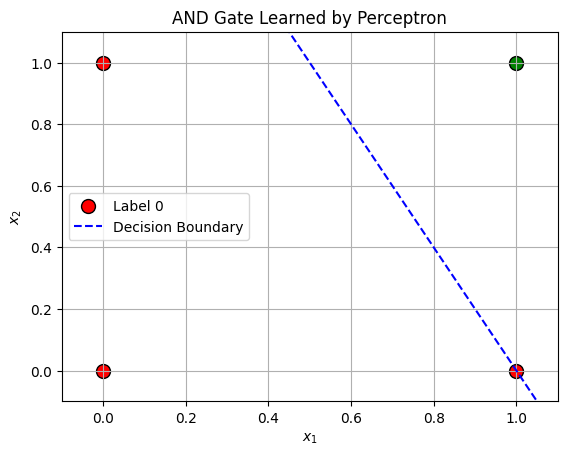

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# Trained weights and bias (example — replace with your actual learned values)
weights= weights
bias = bias  # Chosen so that only [1, 1] triggers output

# Inputs and labels for AND gate
inputs_g = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
labels_g = np.array([0, 0, 0, 1])

# Plot data points
for i, label in enumerate(labels_g):
    color = 'red' if label == 0 else 'green'
    plt.scatter(inputs[i, 0], inputs[i, 1], c=color, s=100, edgecolors='k', label=f'Label {label}' if i == 0 else "")

# Plot decision boundary
x_vals = np.linspace(-0.1, 1.1, 100)
y_vals = -(weights[0] * x_vals + bias) / weights[1]
plt.plot(x_vals, y_vals, 'b--', label='Decision Boundary')

plt.title("AND Gate Learned by Perceptron")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.grid(True)
plt.legend()
plt.show()


### The blue dashed line we've plotted is the set of points where the linear output = 0:

🧠 **Key takeaway:**  
The perceptron finds a **linear decision boundary** that separates input space based on whether the output should be `0` or `1`.

---

However, this example also highlights the **limits** of a single-layer perceptron:

- It works for linearly separable problems like **AND** and **OR**
- But it **cannot solve XOR**, where the output is not separable by a straight line

To solve problems like XOR, we need **multi-layer perceptrons (MLPs)** — deeper models that can learn nonlinear decision boundaries using hidden layers and more powerful activation functions.


❓ **Challenge Question: Why can't a single-layer perceptron model the XOR function?**

The XOR gate outputs `1` only when the inputs are different:

| Input A | Input B | XOR Output |
|---------|---------|------------|
|   0     |    0    |     0      |
|   0     |    1    |     1      |
|   1     |    0    |     1      |
|   1     |    1    |     0      |

Try plotting these four input combinations on a 2D graph. Can you draw a single straight line that separates the `1`s from the `0`s?

Use your answer to explain why a single-layer perceptron, which creates only a linear boundary, is unable to learn XOR — and why deeper networks are necessary.


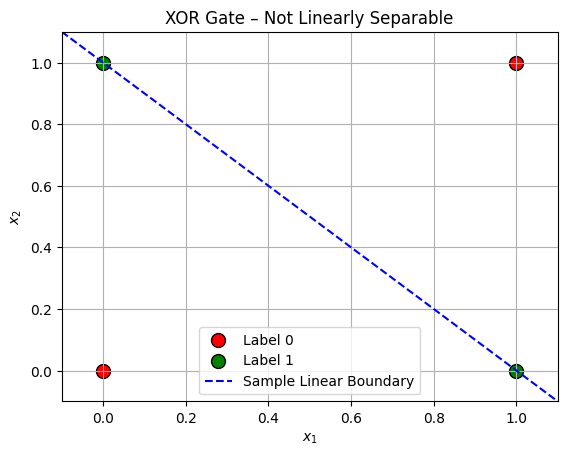

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# XOR inputs and labels
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y = np.array([0, 1, 1, 0])

# Plot the inputs
for i in range(len(X)):
    color = 'green' if y[i] == 1 else 'red'
    plt.scatter(X[i, 0], X[i, 1], color=color, s=100, edgecolors='k', label=f"Label {y[i]}" if i < 2 else "")

plt.title("XOR Gate – Not Linearly Separable")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.grid(True)

# OPTIONAL: draw a fake linear boundary to show futility
# e.g. x1 + x2 - 1 = 0 → x2 = 1 - x1
x_vals = np.linspace(-0.1, 1.1, 100)
y_vals = 1 - x_vals
plt.plot(x_vals, y_vals, 'b--', label="Sample Linear Boundary")

plt.legend()
plt.show()


In [ ]:
### AI Winter and the XOR Problem (Brief Note)
In the late 1960s, researchers like Minsky and Papert showed that single-layer perceptrons couldn't solve simple 
problems like XOR, which is not linearly separable. Since there was no known way to train multi-layer networks at the time,
this limitation led to widespread skepticism about neural networks.

### This contributed to the AI Winter — a period where interest and funding in neural networks sharply declined.

It wasn’t until the 1980s, when the backpropagation algorithm (which uses partial derivatives to propagate error through hidden layers) was popularized by Rumelhart, Hinton, and Williams, that neural networks began to regain credibility and become useful in practice.

# Homework!

## 📘 Problem Set: Train Your Brain (and Your Perceptron!)

1. **Modify the Truth Table**
   - Replace the `labels` array to model an **OR** gate instead of an AND gate.  
   - Run the training again. Does the perceptron learn it correctly?


In [48]:
# We are modeling an OR gate, so we define all combinations of two binary inputs and the correct outputs (labels) for each.

# Define training inputs
inputs = np.array([
    [0, 0],
    [0, 0],
    [0, 0],
    [0, 0]
])

# Labels for AND logic
labels = np.array([0, 0, 0, 0])

# Initialize weights and bias
weights = np.zeros(2)
bias = 0.0
# Learning rate controls how big each update is
learning_rate = 0.1

# Training loop
epochs = 50
for _ in range(epochs):
    for x, y in zip(inputs, labels):
        linear_output = np.dot(x, weights) + bias
        prediction = 1 if linear_output > 0 else 0
        error = y - prediction

        # Perceptron learning rule
        weights += learning_rate * error * x
        bias += learning_rate * error
print('Epochs complete.')

# Testing
for truth_condition in inputs:
    result = 1 if np.dot(truth_condition, weights) + bias > 0 else 0
    print(f"{x} -> {result}")


Epochs complete.
[0 0] -> 0
[0 0] -> 0
[0 0] -> 0
[0 0] -> 0


2. **Try a Bad Initialization**
   - Set the initial weights to `np.array([5.0, -3.0])` and `bias = 2.0`.  
   - What happens to the training? Can the perceptron still learn?
